# Mental Disorder Classification from Reddit Posts
## Baseline Model: TF-IDF + Logistic Regression

**Team Project | Neural Networks Course**

This notebook implements the baseline model for classifying Reddit posts into one of six mental disorder categories using TF-IDF features and a Logistic Regression classifier.

**Classes:** BPD, Anxiety, Depression, MentalIllness, Bipolar, Schizophrenia

## 1. Imports & Setup

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
SAMPLE_SIZE  = 50000  # stratified sample — change if needed
print('All imports successful.')

All imports successful.


## 2. Load Dataset

In [2]:
path = kagglehub.dataset_download("kamaruladha/mental-disorders-identification-reddit-nlp")
df_full = pd.read_csv(os.path.join(path, "mental_disorders_reddit.csv"))
print(f"Full dataset shape: {df_full.shape}")
df_full.head()

Full dataset shape: (701787, 5)


,title,selftext,created_utc,over_18,subreddit
0,Life is so pointless without others,Does anyone else think the most important part...,1650356960,False,BPD
1,Cold rage?,Hello fellow friends 😄\n\nI'm on the BPD spect...,1650356660,False,BPD
2,I don’t know who I am,My [F20] bf [M20] told me today (after I said ...,1650355379,False,BPD
3,HELP! Opinions! Advice!,"Okay, I’m about to open up about many things I...",1650353430,False,BPD
4,help,[removed],1650350907,False,BPD


## 3. Preprocessing

In [3]:
# Fill nulls and combine title + body
df_full['title']    = df_full['title'].fillna('')
df_full['selftext'] = df_full['selftext'].fillna('')
df_full['text']     = df_full['title'] + ' ' + df_full['selftext']

# Drop rows with empty text
df_full = df_full[df_full['text'].str.strip() != '']

print("Class distribution (full dataset):")
print(df_full['subreddit'].value_counts())

Class distribution (full dataset):
subreddit
BPD              241116
Anxiety          173986
depression       156972
mentalillness     53232
bipolar           51112
schizophrenia     25365
Name: count, dtype: int64


In [4]:
# --- Stratified sample ---
# Sample proportionally per class, capped at SAMPLE_SIZE total
samples = []
for label, group in df_full.groupby('subreddit'):
    n = min(len(group), int(SAMPLE_SIZE * len(group) / len(df_full)))
    samples.append(group.sample(n=n, random_state=RANDOM_STATE))

df = pd.concat(samples).reset_index(drop=True)

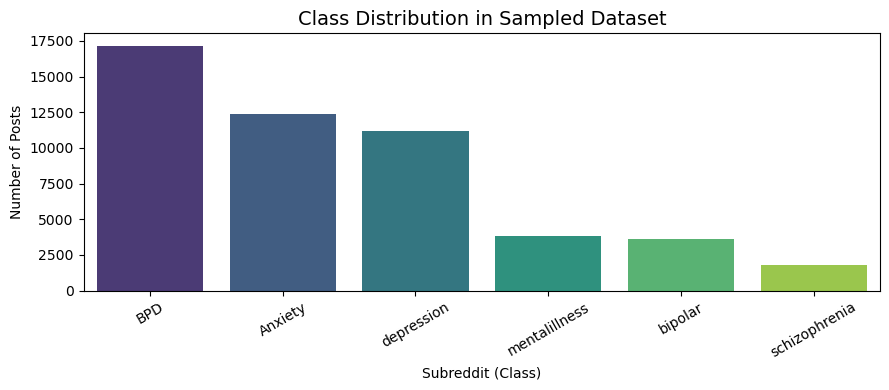

In [5]:
# Plot class distribution
plt.figure(figsize=(9, 4))
order = df['subreddit'].value_counts().index
sns.countplot(data=df, x='subreddit', order=order, palette='viridis')
plt.title('Class Distribution in Sampled Dataset', fontsize=14)
plt.xlabel('Subreddit (Class)')
plt.ylabel('Number of Posts')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Text Cleaning

In [6]:
def clean_text(text):
    """Basic text cleaning for NLP."""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # remove URLs
    text = re.sub(r'\[deleted\]|\[removed\]', '', text) # Reddit artifacts
    text = re.sub(r'[^a-z\s]', '', text)                # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()            # collapse whitespace
    return text

df['clean_text'] = df['text'].apply(clean_text)

# Preview
print("Sample raw text:")
print(df['text'].iloc[0][:200])
print("\nSample cleaned text:")
print(df['clean_text'].iloc[0][:200])

Sample raw text:
Thoughts/Experiences with CBD? I just started recently having bad physical anxiety (heart racing, shortness of breath, feeling like I can’t focus/am gonna faint, etc.) and it mostly comes on when I am

Sample cleaned text:
thoughtsexperiences with cbd i just started recently having bad physical anxiety heart racing shortness of breath feeling like i cant focusam gonna faint etc and it mostly comes on when i am driving o


## 5. Train / Validation / Test Split (70 / 15 / 15)

In [7]:
X = df['clean_text']
y = df['subreddit']

# 70% train, 30% temp — then split temp into 50/50 val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train size : {len(X_train)}")
print(f"Val size   : {len(X_val)}")
print(f"Test size  : {len(X_test)}")

Train size : 34997
Val size   : 7499
Test size  : 7500


## 6. Baseline Model: TF-IDF + Logistic Regression

In [8]:
# Build pipeline: TF-IDF vectorizer → Logistic Regression
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),      # unigrams + bigrams
        sublinear_tf=True,       # apply log(TF) scaling
        stop_words='english',
        min_df=2
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced', # handles class imbalance
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

print('Training Logistic Regression baseline...')
lr_pipeline.fit(X_train, y_train)
print('Done!')

Training Logistic Regression baseline...
Done!


## 7. Evaluation

In [9]:
def evaluate_model(pipeline, X_eval, y_eval, split_name='Test'):
    """Print full evaluation metrics for a given split."""
    y_pred = pipeline.predict(X_eval)
    acc    = accuracy_score(y_eval, y_pred)
    macro_f1 = f1_score(y_eval, y_pred, average='macro')
    weighted_f1 = f1_score(y_eval, y_pred, average='weighted')

    print(f'\n===== {split_name} Results =====')
    print(f'Accuracy        : {acc:.4f}')
    print(f'Macro F1        : {macro_f1:.4f}')
    print(f'Weighted F1     : {weighted_f1:.4f}')
    print('\nPer-Class Report:')
    print(classification_report(y_eval, y_pred))
    return y_pred

# Validation
y_val_pred  = evaluate_model(lr_pipeline, X_val,  y_val,  split_name='Validation')
# Test
y_test_pred = evaluate_model(lr_pipeline, X_test, y_test, split_name='Test')


===== Validation Results =====
Accuracy        : 0.6909
Macro F1        : 0.6040
Weighted F1     : 0.7034

Per-Class Report:
               precision    recall  f1-score   support

      Anxiety       0.85      0.79      0.82      1859
          BPD       0.86      0.70      0.77      2576
      bipolar       0.53      0.60      0.56       546
   depression       0.66      0.71      0.68      1678
mentalillness       0.31      0.42      0.36       569
schizophrenia       0.34      0.61      0.44       271

     accuracy                           0.69      7499
    macro avg       0.59      0.64      0.60      7499
 weighted avg       0.73      0.69      0.70      7499


===== Test Results =====
Accuracy        : 0.6941
Macro F1        : 0.6043
Weighted F1     : 0.7050

Per-Class Report:
               precision    recall  f1-score   support

      Anxiety       0.85      0.79      0.82      1860
          BPD       0.86      0.71      0.78      2577
      bipolar       0.53      0.61 

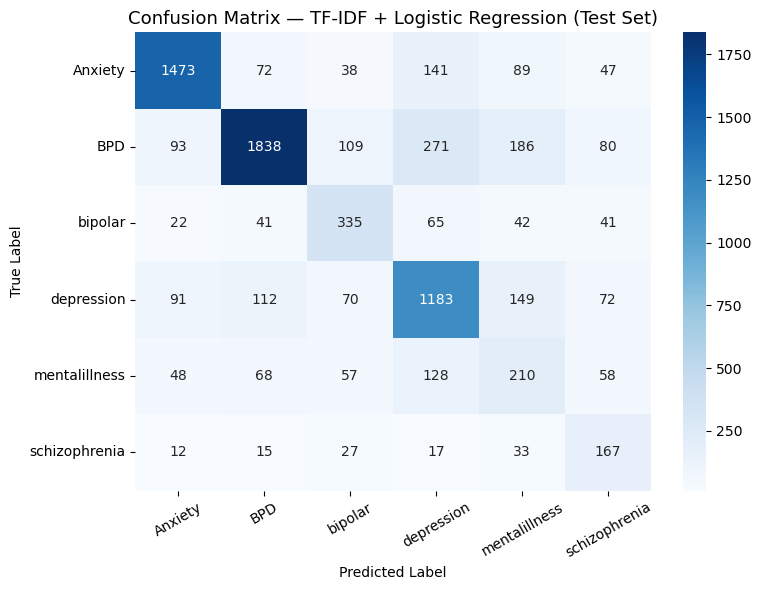

In [10]:
# Confusion Matrix
classes = lr_pipeline.classes_
cm = confusion_matrix(y_test, y_test_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes
)
plt.title('Confusion Matrix — TF-IDF + Logistic Regression (Test Set)', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

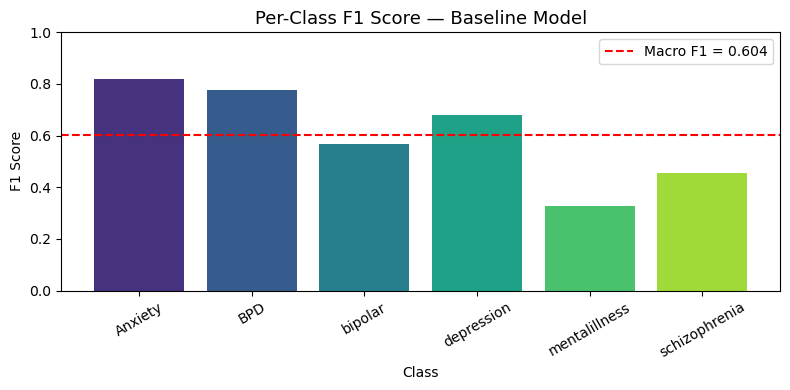

In [11]:
# Per-class F1 bar chart
report = classification_report(y_test, y_test_pred, output_dict=True)
class_f1 = {k: v['f1-score'] for k, v in report.items() if k in classes}

plt.figure(figsize=(8, 4))
bars = plt.bar(class_f1.keys(), class_f1.values(), color=sns.color_palette('viridis', len(class_f1)))
plt.axhline(y=report['macro avg']['f1-score'], color='red', linestyle='--', label=f'Macro F1 = {report["macro avg"]["f1-score"]:.3f}')
plt.title('Per-Class F1 Score — Baseline Model', fontsize=13)
plt.ylabel('F1 Score')
plt.xlabel('Class')
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Comparison: Random Forest Baseline

In [12]:
# TF-IDF + Random Forest (for comparison)
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import issparse

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words='english',
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
print('Training Random Forest... (may take a minute)')
rf.fit(X_train_tfidf, y_train)
y_rf_pred = rf.predict(X_test_tfidf)

rf_macro_f1 = f1_score(y_test, y_rf_pred, average='macro')
rf_acc      = accuracy_score(y_test, y_rf_pred)
print(f'\nRandom Forest — Accuracy: {rf_acc:.4f} | Macro F1: {rf_macro_f1:.4f}')

Training Random Forest... (may take a minute)

Random Forest — Accuracy: 0.6777 | Macro F1: 0.5440



===== Baseline Comparison =====
                       Model  Accuracy  Macro F1
TF-IDF + Logistic Regression  0.694133  0.604275
      TF-IDF + Random Forest  0.677733  0.544001


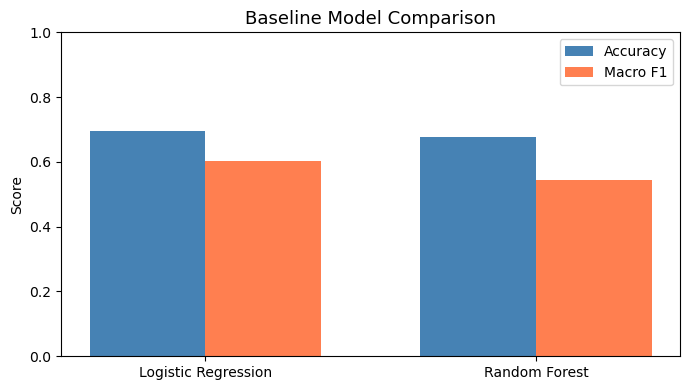

In [13]:
# Summary comparison table
lr_macro_f1 = f1_score(y_test, y_test_pred, average='macro')
lr_acc      = accuracy_score(y_test, y_test_pred)

summary = pd.DataFrame({
    'Model': ['TF-IDF + Logistic Regression', 'TF-IDF + Random Forest'],
    'Accuracy': [lr_acc, rf_acc],
    'Macro F1': [lr_macro_f1, rf_macro_f1]
})

print('\n===== Baseline Comparison =====')
print(summary.to_string(index=False))

# Bar chart comparison
x = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, summary['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, summary['Macro F1'], width, label='Macro F1',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(['Logistic Regression', 'Random Forest'])
ax.set_ylim(0, 1)
ax.set_title('Baseline Model Comparison', fontsize=13)
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Top TF-IDF Features per Class

In [14]:
# Show top 10 most informative words per class
vectorizer = lr_pipeline.named_steps['tfidf']
classifier = lr_pipeline.named_steps['clf']
feature_names = vectorizer.get_feature_names_out()

print('Top 10 most predictive words per class:\n')
for i, class_label in enumerate(classifier.classes_):
    top_indices = np.argsort(classifier.coef_[i])[-10:][::-1]
    top_words   = [feature_names[j] for j in top_indices]
    print(f'{class_label:20s}: {top_words}')

Top 10 most predictive words per class:

Anxiety             : ['anxiety', 'anxious', 'panic', 'nervous', 'fear', 'worried', 'gad', 'stomach', 'worrying', 'overthinking']
BPD                 : ['bpd', 'fp', 'dae', 'dbt', 'borderline', 'splitting', 'boyfriend', 'relationship', 'diagnosed bpd', 'abandonment']
bipolar             : ['bipolar', 'manic', 'mania', 'lamictal', 'lithium', 'hypomania', 'bp', 'stable', 'meds', 'hypomanic']
depression          : ['depression', 'depressed', 'life', 'antidepressants', 'lonely', 'kill', 'hate life', 'depressive', 'dead', 'wish']
mentalillness       : ['mental', 'mental illness', 'depression', 'ocd', 'illnesses', 'mentally ill', 'disorder', 'disorders', 'mentally', 'illness']
schizophrenia       : ['schizophrenia', 'voices', 'schizophrenic', 'psychosis', 'walls', 'schizoaffective', 'delusions', 'sunday', 'hallucinations', 'selfie']


## 10. Summary

The TF-IDF + Logistic Regression baseline provides a strong non-neural starting point for mental disorder classification from Reddit text. Key findings:

- **Primary metric is macro-averaged F1** to account for class imbalance
- The `class_weight='balanced'` setting helps the model handle minority classes (e.g., schizophrenia)
- Bigrams (ngram_range=(1,2)) capture short multi-word patterns common in mental health language
- This baseline will serve as the lower bound for comparison with our BERT-based neural model

**Next step:** Fine-tune BERT (bert-base-uncased or MentalBERT) on the same train/val/test split and compare macro F1 scores.